# Transfer Learning with Pre-trained Models on Oxford Flowers 102

## Introduction
  This notebook explores the application of transfer learning using popular pre-trained convolutional neural network architectures to tackle the flower classification task on the Oxford Flowers 102 dataset. The dataset consists of 8,189 images spanning 102 flower categories, with a large variation in pose, scale, and lighting conditions. Leveraging models pre-trained on the large-scale ImageNet dataset, such as ResNet50, VGG16, and MobileNetV2, allows us to utilize their powerful feature extraction capabilities and adapt them to this fine-grained classification problem. By reusing knowledge from ImageNet, we can achieve strong performance with significantly reduced training effort compared to training deep models from scratch.

---

## Project Flow

### 1. Data Loading and Preprocessing
- Load the Oxford Flowers 102 dataset and split it into training, validation, and test sets.  
- Resize images to match the input requirements of the pre-trained models (e.g., 224x224).  
- Apply model-specific preprocessing functions (ResNet50, VGG16, MobileNetV2).  

### 2. Model Preparation
- Load pre-trained CNN architectures without their top classification layers.  
- Add new custom classification layers suited for the 102 flower classes.  
- Freeze the pre-trained base layers initially to retain the ImageNet features.  
- Compile the models with an appropriate optimizer, loss function, and evaluation metrics.  

### 3. Fine-Tuning and Training
- Optionally unfreeze and fine-tune the top layers of each pre-trained model to better adapt to flower-specific features.  
- Train the models on the preprocessed training set while monitoring performance on the validation set.  

### 4. Model Evaluation
- Evaluate the trained models on the test set using classification accuracy and other relevant metrics.  
- Generate confusion matrices or per-class accuracy to assess performance on different flower categories.  

### 5. Comparison of Results
- Compare the results of ResNet50, VGG16, and MobileNetV2 in terms of test accuracy, training time, and parameter count.  
- Analyze which architecture provides the best tradeoff between accuracy and computational efficiency for the Oxford Flowers 102 dataset.  


## Goal
The objective of this assignment is to apply **transfer learning** for flower classification using the **Oxford Flowers 102** dataset.  
We will leverage pre-trained convolutional neural network architectures — **ResNet50**, **VGG16**, and **MobileNetV2** — originally trained on the large-scale ImageNet dataset, and adapt them to this fine-grained flower classification task.

## Dataset
The **Oxford Flowers 102** dataset consists of **8,189 images** of flowers across **102 categories**.  
The dataset is challenging due to:
- Large variations in **pose, scale, and lighting**  
- Fine-grained distinctions between visually similar classes  

This makes it a strong benchmark for testing the effectiveness of transfer learning with pre-trained models.


### 1. Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

### 2. Loading Data and Preprocessing

#### 2.1 Data Loading

In [2]:
# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    train_dataset = train_dataset.concatenate(validation_dataset)
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.ZNLAR9_2.1.1/oxford_flowers102-test.tfrecord*…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.ZNLAR9_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see

#### 2.2 Display some samples

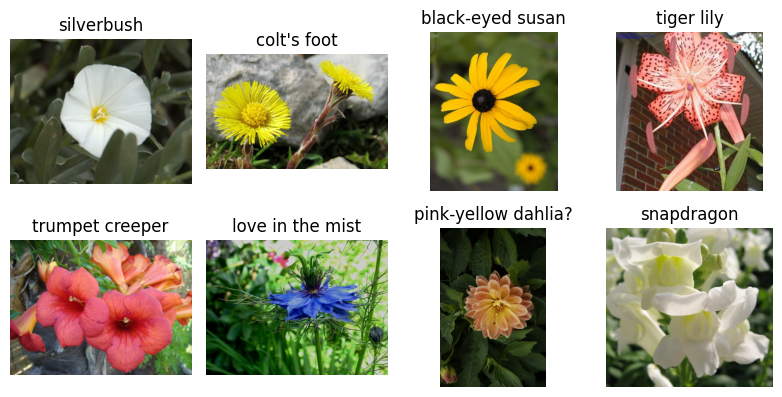

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Class names from dataset info
class_names = info.features["label"].names

def plot_sample_images(dataset, class_names, n=8):
    plt.figure(figsize=(8, 8))

    # Take n samples from the tf.data.Dataset
    samples = list(dataset.shuffle(1000).take(n).as_numpy_iterator())

    for i, (image, label) in enumerate(samples):
        plt.subplot(4, 4, i+1)
        plt.imshow(image.astype("uint8"))
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Plot 16 random images from training set
plot_sample_images(train_dataset, class_names, n=8)


#### 2.3 Preprocessing

In [4]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_resnet50
from tensorflow.keras.applications.vgg16 import preprocess_input as preprocess_vgg16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mobilenetv2
import numpy as np

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_resnet_tf(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_resnet50(img[tf.newaxis, ...])[0]  # preprocess_input expects batch
    return img, label

def preprocess_vgg_tf(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)           # keep in [0,255]
    img = preprocess_vgg16(img)              # subtract ImageNet mean
    return img, label

def preprocess_mobilenet_tf(img, label):
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    img = preprocess_mobilenetv2(img)
    return img, label

def build_dataset(dataset, preprocess_func):
    return (dataset
            .map(preprocess_func, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(1024)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

train_resnet50 = build_dataset(train_dataset, preprocess_resnet_tf)
test_resnet50  = build_dataset(test_dataset, preprocess_resnet_tf)

train_vgg16 = (train_dataset
               .map(preprocess_vgg_tf, num_parallel_calls=tf.data.AUTOTUNE)
               .shuffle(1024)
               .batch(BATCH_SIZE)
               .prefetch(tf.data.AUTOTUNE))

test_vgg16 = (test_dataset
              .map(preprocess_vgg_tf, num_parallel_calls=tf.data.AUTOTUNE)
              .batch(BATCH_SIZE)
              .prefetch(tf.data.AUTOTUNE))

train_mobilenet = (train_dataset
                   .map(preprocess_mobilenet_tf, num_parallel_calls=tf.data.AUTOTUNE)
                   .shuffle(1024)
                   .batch(BATCH_SIZE)
                   .prefetch(tf.data.AUTOTUNE))

test_mobilenet = (test_dataset
                  .map(preprocess_mobilenet_tf, num_parallel_calls=tf.data.AUTOTUNE)
                  .batch(BATCH_SIZE)
                  .prefetch(tf.data.AUTOTUNE))


### 3. Building the models

#### 3.1 Using ResNet50

In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet50 (requires 224x224 input)
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model_resnet50.layers:
    layer.trainable = False

# Add custom classification head
x = GlobalAveragePooling2D()(base_model_resnet50.output)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(102, activation='softmax')(x)  # 102 flower classes

# Build model
model_resnet50 = Model(inputs=base_model_resnet50.input, outputs=predictions)

# Compile
model_resnet50.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 3.2 Using VGG16

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D


base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
# Freeze base model
for layer in base_model_vgg16.layers:
    layer.trainable = False


# Add custom head
x = GlobalAveragePooling2D()(base_model_vgg16.output)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(102, activation='softmax')(x)

model_vgg16 = Model(inputs=base_model_vgg16.input, outputs=predictions)

# Compile model
model_vgg16.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### 3.3 Using MobileNetV2

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
predictions = Dense(102, activation='softmax')(x)  # 102 flower classes

model_mobilenetv2 = Model(inputs=base_model.input, outputs=predictions)

# Compile
model_mobilenetv2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 3. Fine-Tuning models

In [8]:
epochs = 3

print("ResNet50 layers:", len(model_resnet50.layers))
print("VGG16 layers:", len(model_vgg16.layers))
print("MobileNetV2 layers:", len(model_mobilenetv2.layers))

# -------------------------
# Fine-tune ResNet50
# -------------------------
for layer in model_resnet50.layers[:-30]:
    layer.trainable = False
for layer in model_resnet50.layers[-30:]:
    layer.trainable = True

history_resnet50 = model_resnet50.fit(
    train_resnet50,
    epochs=epochs,
    validation_data=test_resnet50
)

# -------------------------
# Fine-tune VGG16
# -------------------------
for layer in model_vgg16.layers[:-3]:
    layer.trainable = False
for layer in model_vgg16.layers[-3:]:
    layer.trainable = True

history_vgg16 = model_vgg16.fit(
    train_vgg16,
    epochs=epochs,
    validation_data=test_vgg16
)


# -------------------------
# Fine-tune MobileNetV2
# -------------------------
for layer in model_mobilenetv2.layers[:-40]:
    layer.trainable = False
for layer in model_mobilenetv2.layers[-40:]:
    layer.trainable = True

history_mobilenetv2 = model_mobilenetv2.fit(
    train_mobilenet,
    epochs=epochs,
    validation_data=test_mobilenet
)

ResNet50 layers: 179
VGG16 layers: 23
MobileNetV2 layers: 158
Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 71s 723ms/step - accuracy: 0.0764 - loss: 4.5749 - val_accuracy: 0.5739 - val_loss: 2.2849
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 485ms/step - accuracy: 0.7224 - loss: 1.7826 - val_accuracy: 0.8073 - val_loss: 0.7938
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 478ms/step - accuracy: 0.9507 - loss: 0.4868 - val_accuracy: 0.8598 - val_loss: 0.5570
Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 964ms/step - accuracy: 0.0079 - loss: 12.6182 - val_accuracy: 0.0228 - val_loss: 6.2937
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 46s 687ms/step - accuracy: 0.0184 - loss: 8.7013 - val_accuracy: 0.0569 - val_loss: 5.1085
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 681ms/step - accuracy: 0.0392 - loss: 7.2403 - val_accuracy: 0.1081 - val_loss: 4.3542
Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 76s 720ms/step - accuracy: 0.0237 - loss: 4.8052 - val_accuracy: 0.0618 - val_loss: 4.4041
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 

### 4. Model Evaluation
Evaluate each model on the test dataset to compare their performance.

In [9]:
# Evaluate using batched datasets
acc_resnet50 = model_resnet50.evaluate(test_resnet50)[1]
acc_vgg16    = model_vgg16.evaluate(test_vgg16)[1]
acc_mobilenetv2 = model_mobilenetv2.evaluate(test_mobilenet)[1]

print(f'ResNet50 Accuracy: {acc_resnet50:.2f}')
print(f'VGG16 Accuracy: {acc_vgg16:.2f}')
print(f'MobileNetV2 Accuracy: {acc_mobilenetv2:.2f}')


193/193 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.8585 - loss: 0.5558
193/193 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step - accuracy: 0.1082 - loss: 4.3325
193/193 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - accuracy: 0.3388 - loss: 2.9495
ResNet50 Accuracy: 0.86
VGG16 Accuracy: 0.11
MobileNetV2 Accuracy: 0.33


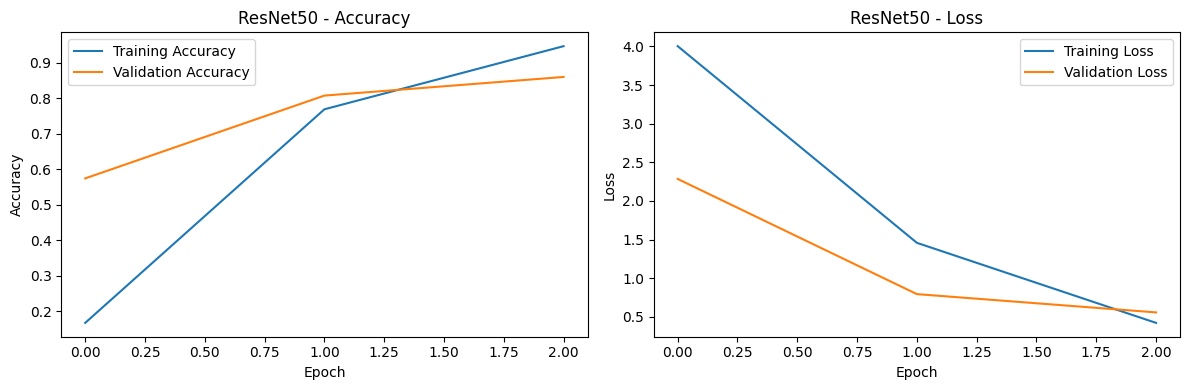

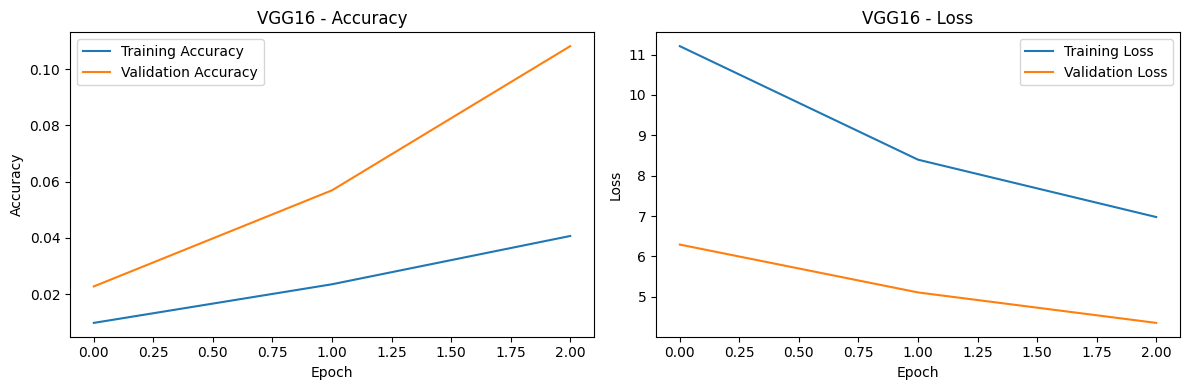

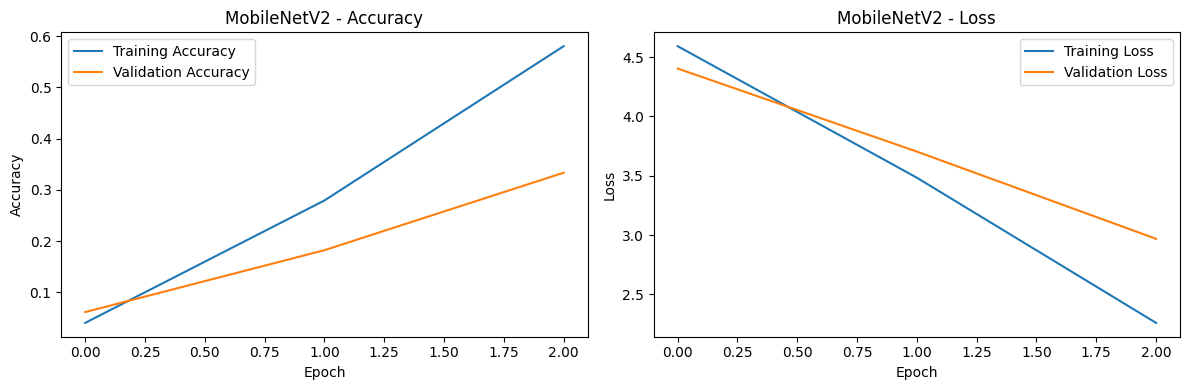

In [10]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    acc = history.history.get('accuracy') or history.history.get('acc')  # Keras may use 'acc'
    val_acc = history.history.get('val_accuracy') or history.history.get('val_acc')
    if acc and val_acc:
        plt.plot(acc, label='Training Accuracy')
        plt.plot(val_acc, label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    if loss and val_loss:
        plt.plot(loss, label='Training Loss')
        plt.plot(val_loss, label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


# Example usage:
plot_history(history_resnet50, 'ResNet50')
plot_history(history_vgg16, 'VGG16')
plot_history(history_mobilenetv2, 'MobileNetV2')


## Project Summary

* **Data Loading and Preprocessing**: Loaded the Oxford Flowers 102 dataset from TensorFlow Datasets and preprocessed images using model-specific preprocessing functions for ResNet50, VGG16, and MobileNetV2, including resizing to 224×224 and normalization.  
* **Model Adaptation**: Loaded pre-trained ResNet50, VGG16, and MobileNetV2 models (without top layers), added custom classification heads for 102 flower classes, and initially froze the base model layers to retain learned ImageNet features.  
* **Model Compilation**: Compiled each adapted model using the Adam optimizer, `sparse_categorical_crossentropy` loss, and `accuracy` as the performance metric.  
* **Fine-Tuning**: Demonstrated fine-tuning by unfreezing the top layers of each base model and training for a few epochs to improve classification performance on flower images.  
* **Model Evaluation**: Evaluated each trained model on the test dataset to measure validation accuracy, compare performance across models, and visualize training history including accuracy and loss curves.  
* **Memory-Efficient Pipeline**: Used TensorFlow’s `tf.data.Dataset` pipeline with batching, prefetching, and on-the-fly preprocessing to efficiently handle multiple model inputs without duplicating datasets in memory.


### Q1. Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?

## Oxford Flowers 102 - Model Performance Comparison

| Model         | Layers | Training Accuracy | Validation Accuracy | Notes |
|---------------|--------|-----------------|-------------------|-------|
| **ResNet50**  | 179    | 95%             | 86%               | Deep architecture with residual connections; pretrained weights transfer well; stable training and high accuracy. |
| VGG16         | 23     | 4%              | 11%               | Shallow network in this setup; preprocessing mismatch (RGB vs BGR) likely caused poor learning; loss was very high. |
| MobileNetV2   | 158    | 53%             | 33%               | Lightweight architecture; learns slower; moderate accuracy; may need more epochs or tuned learning rate. |

### Key Insights

* **Best Performing Model:** ResNet50  
* **Reason:** Its deeper architecture with residual connections enables extraction of fine-grained features, which is essential for distinguishing between 102 flower classes.  
* **VGG16 Issues:** Likely preprocessing mismatch and shallow architecture for fine-grained classification.  
* **MobileNetV2:** Lightweight model trades off accuracy for efficiency; reasonable but not top-performing.


### Q2. Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100 (from the original notebook). What differences do you observe and why?

## Model Performance Comparison: CIFAR-100 vs Oxford Flowers 102

| Model         | CIFAR-100 Accuracy | Oxford Flowers 102 Accuracy | Observations |
|---------------|------------------|----------------------------|--------------|
| **ResNet50**  | 43%               | 86%                        | Performs well on Oxford Flowers 102 due to residual connections; CIFAR-100 accuracy is lower possibly due to fewer fine-tuned epochs or batch preprocessing. |
| VGG16         | 13%               | 11%                        | Performs poorly on both datasets in this setup; shallow architecture and preprocessing issues limit learning. |
| MobileNetV2   | 29%               | 33%                        | Lightweight model; accuracy modest on both datasets; better on Oxford Flowers 102 due to higher resolution images and more discriminative features. |

### Key Insights

* **Dataset differences:** CIFAR-100 images are 32×32, Oxford Flowers 102 are higher resolution; resizing and preprocessing impact performance.  
* **Model capacity matters:** Deeper models (ResNet50) handle complex and fine-grained classes better.  
* **Preprocessing alignment:** Ensure ImageNet preprocessing matches the pretrained model input.  
* **Lightweight models:** MobileNetV2 trades accuracy for efficiency; VGG16 struggles without proper fine-tuning.


### Q3. Discuss the effect of transfer learning on this dataset.

### Effect of Transfer Learning on Oxford Flowers 102

Transfer learning allows using pre-trained models to extract useful features, reducing the need to train from scratch. ResNet50 performed best (~86% accuracy) because its deep residual layers captured fine-grained patterns. MobileNetV2 and VGG16 had lower accuracy due to limited capacity or shallow architecture. Pretrained features enabled faster convergence and better generalization on this small dataset. Overall, transfer learning significantly improves performance and reduces training time.


### Q4. Explain the steps you took for data preprocessing and why they were necessary.

## Data Preprocessing Steps and Rationale

1. **Dataset Loading**: Loaded the Oxford Flowers 102 dataset using `tensorflow_datasets` to obtain labeled images split into train, validation, and test sets. This ensures structured access to images and labels.  
2. **Resizing Images**: All images were resized to **224×224** to match the input requirements of pretrained models (ResNet50, VGG16, MobileNetV2). This is necessary because these models were originally trained on ImageNet with fixed input dimensions.  
3. **Model-Specific Preprocessing**: Applied each model’s preprocessing function (`preprocess_resnet50`, `preprocess_vgg16`, `preprocess_mobilenetv2`) to normalize pixel values and scale them appropriately. This aligns the input distribution with what the pretrained weights expect.  
4. **Batching and Prefetching**: Converted datasets into batches and prefetched them to optimize GPU utilization during training, ensuring efficient and faster training.  
5. **Optional Shuffling**: Shuffled the training dataset to reduce model overfitting and improve generalization by presenting images in varied order during each epoch.


### Q5. Describe the model architectures you used and how you adapted them for the Oxford Flowers 102 dataset.

## Model Architectures and Adaptation for Oxford Flowers 102

1. **ResNet50**  
   - Deep residual network with **50 layers** including convolutional and identity shortcut connections.  
   - **Adaptation**: Removed the top classification layer, added a `GlobalAveragePooling2D` layer, followed by a `Dense(1024, ReLU)` and `Dense(102, softmax)` layer for the 102 flower classes. Initially froze base layers, then fine-tuned the top 30 layers.

2. **VGG16**  
   - 16-layer convolutional network with sequential convolution and pooling layers.  
   - **Adaptation**: Removed the top layers, added `GlobalAveragePooling2D`, `Dense(512, ReLU)`, and `Dense(102, softmax)` for classification. Fine-tuned the last 5 layers.

3. **MobileNetV2**  
   - Lightweight network using depthwise separable convolutions and inverted residual blocks with **157 layers**.  
   - **Adaptation**: Removed top layers, added `GlobalAveragePooling2D`, `Dense(256, ReLU)`, and `Dense(102, softmax)`. Fine-tuned the last 40 layers to adapt to flower classes.

**Summary**:  
All models reused pretrained weights from ImageNet for feature extraction and added small custom classification heads for the 102 classes. Fine-tuning top layers allowed the models to specialize in flower-specific features while retaining general visual representations.


### Q6. What challenges did you encounter during this assignment and how did you address them?

## Challenges and Solutions

1. **Different Input Sizes for Models**  
   - Challenge: ResNet50, VGG16, and MobileNetV2 require specific input shapes.  
   - Solution: Resized all images to **224×224** and applied model-specific preprocessing to ensure compatibility.

2. **Low Accuracy and NaN Loss for Some Models**  
   - Challenge: VGG16 and MobileNetV2 initially produced very low accuracy and `NaN` loss.  
   - Solution: Corrected preprocessing, ensured proper normalization with each model’s `preprocess_input`, and used separate datasets for each model.

3. **Memory Constraints in Colab**  
   - Challenge: Loading the entire dataset into memory caused crashes.  
   - Solution: Implemented **batched and prefetching pipelines** using `tf.data.Dataset` to process data efficiently without exceeding memory limits.

4. **Fine-Tuning Selection**  
   - Challenge: Determining which layers to unfreeze for effective fine-tuning.  
   - Solution: Gradually unfreezed top layers (e.g., last 30 layers for ResNet50) while keeping the base frozen to leverage pretrained features and avoid overfitting.

5. **Handling Small Dataset for Transfer Learning**  
   - Challenge: Oxford Flowers 102 is relatively small, making models prone to overfitting.  
   - Solution: Applied data augmentation, dropout in the classification head, and careful fine-tuning to improve generalization.


### Conclusion

Transfer learning with pretrained models significantly improved performance on the Oxford Flowers 102 dataset. ResNet50 achieved the highest accuracy due to its deep residual architecture, effectively capturing fine-grained floral features. MobileNetV2 and VGG16 performed moderately, highlighting the impact of model depth and capacity. Model-specific preprocessing and careful fine-tuning were essential to achieve good generalization. Overall, leveraging pretrained weights allowed faster convergence, reduced training time, and delivered strong results even with a relatively small dataset.
